# Homework 2A: Compare Browsing Sessions

Find browsing sessions similar to session **58**. Compare Euclidean distance, scaling, Manhattan distance, and cosine similarity, as in Lectures 03a and 03b. Then apply Jaccard similarity to a small purchase example.

Most code is supplied. Adapt the example calls and answer the questions below. You do not need your HW1B notebook.

## Data and setup

Each row describes one online shopping session using the recorded time spent on administrative, informational, and product-related pages. The data come from the [UCI Online Shoppers Purchasing Intention Dataset](https://doi.org/10.24432/C5F88Q) by Sakar and Kastro, licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). This is the same source used in HW1B, with different columns selected.

The prepared file contains 11,610 sessions. We removed 720 rows with zero in all three duration columns so cosine is defined for every session. All comparisons use the same remaining rows. Values retain the source's duration units. `session_id` is a row label added by the course; it is not a feature. These records describe one site's sessions during one year, not all online shopping behavior.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from scipy.spatial.distance import cdist

sessions = pd.read_csv(
    "https://raw.githubusercontent.com/olearydj/INSY7130/"
    "main/homework/hw2a/data/browsing-session-durations.csv"
)
FEATURES = ["administrative", "informational", "product_related"]
ANCHOR = 58
K = 3
durations = sessions.set_index("session_id")[FEATURES]
feature_means = durations.mean()
feature_scales = durations.std(ddof=0)
standardized = (durations - feature_means) / feature_scales

display(durations.loc[[ANCHOR]])
display(pd.DataFrame({"minimum": durations.min(), "maximum": durations.max(),
                      "standard_deviation": feature_scales}).round(3))

,administrative,informational,product_related
session_id,,,
58,56.0,120.0,998.741667


,minimum,maximum,standard_deviation
administrative,0.0,3398.750,180.986
informational,0.0,2549.375,144.772
product_related,0.0,63973.522,1948.053


Rows in `durations` are sessions; columns are the three duration features. `durations.loc[[ANCHOR]]` selects session 58 as a one-row table. The supplied setup subtracts each column's mean and uses that column's standard deviation to create `standardized`.

The helpers below calculate and display the three nearest other sessions. `rank_neighbors` accepts a data matrix and a distance name, such as `"euclidean"` or `"cosine"`. `show_profiles` displays selected sessions and plots the percentage of each session's recorded time spent in each page category.

In [2]:
def rank_neighbors(matrix, metric):
    distances = cdist(matrix.loc[[ANCHOR]], matrix, metric=metric).ravel()
    ranking = pd.Series(distances, index=matrix.index, name="distance")
    ranking = ranking.drop(index=ANCHOR).sort_values(kind="stable").head(K)
    table = ranking.rename_axis("session_id").reset_index()
    table.index = pd.RangeIndex(1, len(table) + 1, name="rank")
    if metric == "cosine":
        table["similarity"] = 1 - table["distance"]
    return table


def show_ranking(table):
    with pd.option_context("display.float_format", "{:.8f}".format):
        display(table)


def show_profiles(candidate_ids):
    ids = list(dict.fromkeys([ANCHOR, *candidate_ids]))
    selected = durations.loc[ids]
    totals = selected.sum(axis=1)
    shares = selected.div(totals, axis=0)
    display(selected.assign(total_duration=totals).round(3))
    axis = shares.mul(100).plot.bar(
        figsize=(9, 4), color=["#0072B2", "#D55E00", "#009E73"], rot=0
    )
    axis.set_xlabel("Session ID")
    axis.set_ylabel("Share of recorded duration (%)")
    axis.set_ylim(0, 100)
    axis.set_title("Allocation across the three page categories")
    axis.legend(title="Page category", loc="upper left", bbox_to_anchor=(1.02, 1))
    axis.figure.tight_layout()
    plt.show()

## 1. Euclidean distance, scaling, and Manhattan distance

Run the raw Euclidean comparison below. Then adapt the call to find the nearest sessions using `standardized`. Save that result as `standardized_neighbors` and display it with `show_ranking`.

In [3]:
raw_neighbors = rank_neighbors(durations, "euclidean")
show_ranking(raw_neighbors)

,session_id,distance
rank,,
1,1918,30.18036785
2,7474,43.06394344
3,1811,44.96776700


In [4]:
# Obtain and display standardized_neighbors using the supplied example.
standardized_neighbors = rank_neighbors(standardized, "euclidean")
show_ranking(standardized_neighbors)

,session_id,distance
rank,,
1,1918,0.03669091
2,5160,0.16062695
3,604,0.16649912


**1a.** Does any session appear in both lists?

> Yes. Session 1918 appears in both the raw Euclidean and standardized Euclidean neighbor lists. The other nearest sessions changed after standardization, indicating that scaling the features affected the similarity comparison.

**1b.** Why can standardizing the features change the nearest sessions? Use the feature summary above to identify which duration has the largest variation. Does standardizing automatically make the comparison better? Explain briefly.

> Standardizing can change the nearest sessions because Euclidean distance is affected by the scale and variability of the features. The product_related duration has the largest standard deviation (1948.053), so differences in that feature have much more influence on the raw Euclidean distances than the other two features. Standardizing places all features on the same scale so that each contributes more equally to the comparison. However, standardizing does not automatically make the comparison better. It depends on the goal of the analysis and whether equal weighting of the features is appropriate.

Use `rank_neighbors` with `standardized` and `"cityblock"` (SciPy's name for Manhattan distance) to obtain `manhattan_neighbors`. Display the result with `show_ranking`.

In [5]:
# Obtain and display manhattan_neighbors using standardized durations.
manhattan_neighbors = rank_neighbors(standardized, "cityblock")
show_ranking(manhattan_neighbors)

,session_id,distance
rank,,
1,1918,0.06158992
2,5160,0.25710898
3,604,0.28138670


**1c.** Which neighbors appear in both the standardized Euclidean and Manhattan lists? Briefly explain how the two measures combine feature differences differently.

> The Manhattan distance and standardized Euclidean distance produced the same three nearest sessions (1918, 5160, and 604). Although the distance values are different, both methods identified the same neighbors for Session 58. Euclidean distance measures straight-line distance and squares differences before combining them, while Manhattan distance sums the absolute differences across features.

**Code question 1.** In the line `standardized = (durations - feature_means) / feature_scales`, what happens to each column? Explain the subtraction and division in two or three sentences.

> The subtraction (durations - feature_means) centers each column by subtracting that feature's mean from every value, so the column has a mean of zero. The division by feature_scales then scales each column by its standard deviation, so the values are measured in standard deviation units. This standardization puts all features on a comparable scale and prevents features with larger variation from dominating the distance calculations.

## 2. Cosine similarity

Use `rank_neighbors(durations, "cosine")` to obtain `cosine_neighbors`, then display it with `show_ranking`. Use the original durations for this comparison.

In [6]:
# Obtain and display cosine_neighbors using the supplied example.
cosine_neighbors = rank_neighbors(durations, "cosine")
show_ranking(cosine_neighbors)

,session_id,distance,similarity
rank,,,
1,1712,0.00000035,0.99999965
2,1918,0.00000620,0.99999380
3,2822,0.00002579,0.99997421


Use `show_profiles` to compare the first- and second-ranked sessions from your cosine results. The table shows durations and totals; the bars show percentages of each session's total. These percentages are not cosine scores.

,administrative,informational,product_related,total_duration
session_id,,,,
58,56.0,120.000,998.742,1174.742
1712,26.0,55.000,457.000,538.000
1918,51.0,117.286,969.102,1137.388


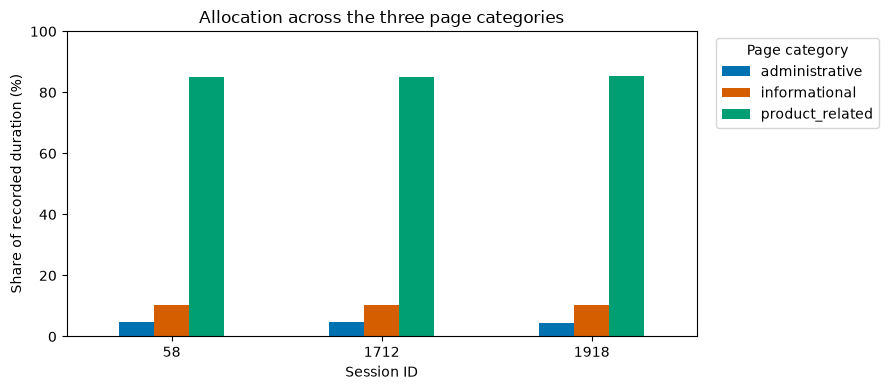

In [7]:
# Use show_profiles to compare the first- and second-ranked cosine sessions.
show_profiles([1712, 1918])

**2a.** How does this list compare with the raw Euclidean distance result?

> The cosine similarity list is different from the raw Euclidean distance list. Only session 1918 appears in both top-three rankings. The highest-ranked cosine session is 1712, which was not in the raw Euclidean top three. This difference occurs because cosine similarity focuses on the pattern of time allocation across page categories, while Euclidean distance focuses on differences in the actual duration values.

**2b.** Use the table and figure to explain how session 58 and the first-ranked cosine session can have high cosine similarity even though their total durations differ. Would Euclidean distance ignore this difference in total duration?

> Session 58 has a total duration of 1174.742, while session 1712 has a total duration of 538.000. Despite this difference, the figure shows that both sessions allocate nearly the same percentage of their time to administrative, informational, and product-related pages. Cosine similarity measures the similarity of these proportions or directions, so the sessions can have a very high cosine similarity even when their total times differ. Euclidean distance would not ignore the difference in total duration because it uses the actual duration values, so larger differences in time spent contribute to a larger distance.

**2c.** Does appearing in the top three guarantee that a session is useful for a particular business question? Explain briefly.

> No. Appearing in the top three only means that a session is similar according to the chosen similarity measure and features. Whether the session is useful depends on the specific question, the variables used, and whether the similarity measure matches the decision-making goal.

**Code question 2.** In `rank_neighbors`, why do we use `drop(index=ANCHOR)`? Why is sorting distance from smallest to largest appropriate, even though larger cosine similarities indicate a closer match? Use the `1 - distance` calculation in your explanation. Two or three sentences are sufficient.

> We use drop(index=ANCHOR) to remove session 58 from the ranking because a session would otherwise be compared to itself and have a distance of zero, making it automatically the closest match. Sorting from smallest to largest distance is appropriate because cosine distance equals 1 - similarity. A smaller cosine distance corresponds to a larger cosine similarity, so the most similar sessions appear first when distances are sorted in ascending order.

## 3. Jaccard similarity

In this small made-up purchase example, 1 means a customer bought a product and 0 means they did not. Run the supplied code to compare customers A–D with Target using Jaccard similarity.

In [8]:
purchases = pd.DataFrame(
    [[1, 1, 1, 0, 0, 0, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 0],
     [1, 1, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 1, 0, 0, 0]],
    index=["Target", "A", "B", "C", "D"],
    columns=[f"P{i}" for i in range(1, 9)],
)
others = purchases.drop(index="Target")
jaccard_scores = pd.Series(
    1 - cdist(purchases.loc[["Target"]].to_numpy(dtype=bool),
              others.to_numpy(dtype=bool), metric="jaccard").ravel(),
    index=others.index, name="Jaccard similarity",
).sort_values(ascending=False)
display(purchases)
display(jaccard_scores.round(4).to_frame())

,P1,P2,P3,P4,P5,P6,P7,P8
Target,1,1,1,0,0,0,0,0
A,1,1,1,1,1,1,1,0
B,1,1,0,0,0,0,0,0
C,1,0,0,1,0,0,0,0
D,0,0,0,0,1,0,0,0


,Jaccard similarity
B,0.6667
A,0.4286
C,0.2500
D,0.0000


**3a.** Which customer is most similar to Target?

> Customer B is most similar to Target. Customer B has a Jaccard similarity of 2/3 (0.6667), which is higher than the scores for customers A, C, and D. This checks out against visual inspection as B is only off of the target by 1 purchase.

**3b.** Check customer A's score by identifying the intersection and union of its product set with Target's. Why doesn't the largest number of shared products necessarily give the highest Jaccard similarity?

> For Customer A, the intersection with Target contains 3 products (P1, P2, and P3), and the union contains 7 products (P1 through P7). Therefore, A's Jaccard similarity is 3/7 ≈ 0.4286. Having the largest number of shared products does not necessarily produce the highest Jaccard similarity because Jaccard similarity considers both the shared products and the total number of products purchased by either customer. Customer A shares more products with Target than Customer B, but A also purchased many additional products, which increases the union and lowers the similarity score.

**3c.** No customer bought P8. Why doesn't that shared absence contribute to Jaccard similarity?

> Jaccard similarity only considers products that were purchased by at least one of the two customers. Since neither Target nor any customer purchased P8, it is a shared absence (0,0) and is not included in the intersection or the union. As a result, P8 does not affect the Jaccard similarity score.

## Check and submit

Answer each question briefly; a few sentences are enough for each explanation. Before submitting, restart the runtime and run all cells in order. Check that your answers agree with the session rankings, purchase comparison, and figure, and keep the outputs in your downloaded `.ipynb` file.

You may use course materials, documentation, and LLM assistance for explanation and debugging. Your submitted answers must be your own, and you must be able to explain the work.

**Assistance disclosure:** Identify material assistance and how you checked it. Write `None` if you received no material assistance.

> I used Microsoft Copilot to help interpret the assignment questions, verify the meanings of Euclidean distance, Manhattan distance, cosine similarity, and Jaccard similarity, and review my written explanations. I checked the assistance by running the provided notebook code, comparing all explanations against the actual outputs, rankings, and figures, and ensuring the submitted answers matched the notebook results.

**Optional, ungraded feedback:** Approximately how much active time did you spend, excluding breaks? Which part required the most effort, and was anything unclear?

> Approximately 1.5 to 2 hours of active time. The interpretation questions required the most effort because they required connecting the numerical outputs to the concepts behind each similarity measure. The instructions were generally clear, but distinguishing how cosine similarity differs from Euclidean distance took the most thought.